In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt


In [6]:

# 🔹 Load PSD Features Dataset
psd_features_path = '/Users/puchku-home/Downloads/Frequency Feature  Generalised/PSD_features.csv'
data = pd.read_csv(psd_features_path)


In [7]:

# 🔹 Separate Features and Target
X = data.drop(columns=['target'])  # All columns except 'target' are features
y = data['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [ ]:

# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 0.8984



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      1638
           1       0.95      0.86      0.90      1639

    accuracy                           0.91      3277
   macro avg       0.91      0.91      0.91      3277
weighted avg       0.91      0.91      0.91      3277

Accuracy on Test Data: 0.9072322245956668


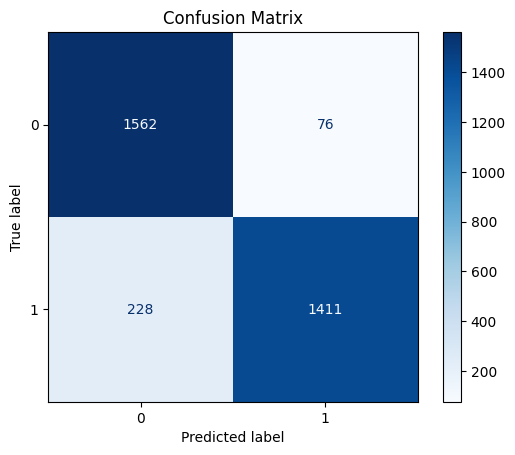

In [9]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


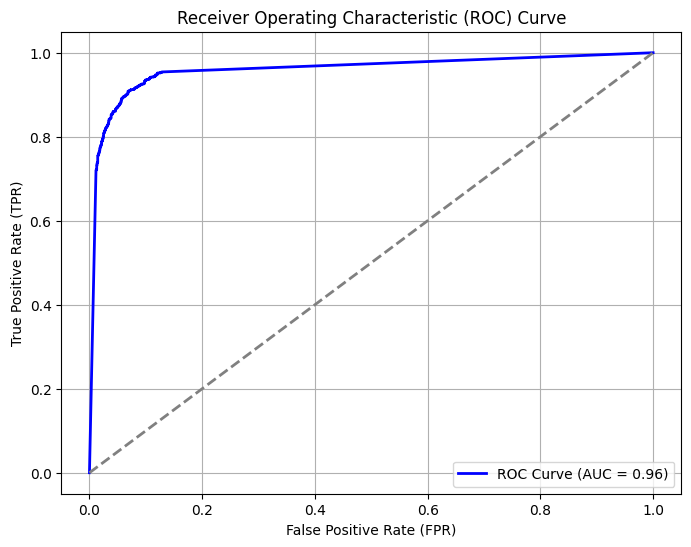

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
